# 📚 Week 08 - Day 01: Natural Language Processing (NLP) using Recurrent Neural Networks (RNNs)

Welcome to today's session! Today we will learn how to teach a Neural Network to understand text. We will build a **Sentiment Analysis** model to predict product ratings based on customer reviews.

### 🎯 Learning Objectives:
1. Understand **Tokenization** (converting text to numbers).
2. Understand **Padding** (making all texts the same length).
3. Learn about **Word Embeddings** (giving meaning to numbers).
4. Build and train a **RNN** for text regression and classification.


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

## 1️⃣ Step 1: Loading the Toy Dataset
We will start with a mock dataset of 1,000 product reviews to understand the basics. Our goal is to predict the `Rating` (1 to 5) from the `ReviewText`.


In [2]:
df = pd.read_csv(r"E:\NAVTTC-AI-Course\datasets\product_reviews_mock_data.csv")
df.head()

,ReviewID,ProductID,UserID,Rating,ReviewText,ReviewDate
0,REV2000,Product_E,User_114,4,fantastic. wonderful experience.,2023-04-17
1,REV2001,Product_C,User_186,2,broke easily. awful.,2023-11-27
2,REV2002,Product_E,User_101,3,met expectations. five stars.,2023-12-10
3,REV2003,Product_A,User_175,5,very satisfied. wonderful experience.,2023-11-10
4,REV2004,Product_C,User_158,1,worst purchase. one star.,2024-05-25


In [3]:
# Let's extract our input features (X) and target labels (y)
X = df["ReviewText"].values
y = df["Rating"].values

print(f"First review: '{X[0]}'")
print(f"Rating: {y[0]}/5")

First review: 'fantastic. wonderful experience.'
Rating: 4/5


## 2️⃣ Step 2: Tokenization (Words to Numbers)
Machine Learning models can't read text directly; they only understand numbers. 
**Tokenization** is the process of mapping every unique word to a specific integer index.


In [4]:
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(X)
vocab_size = len(tokenizer.word_index) + 1
print(f"Total unique words in vocabulary: {vocab_size}")

Total unique words in vocabulary: 74


In [5]:
sequences = tokenizer.texts_to_sequences(X)
print("Max Text Length:", max([len(X[i]) for i in range(len(X[:]))]))
print("Orignal Text: ", X[0])
print("Tokenized Sequence:", sequences[0])

Max Text Length: 73
Orignal Text:  fantastic. wonderful experience.
Tokenized Sequence: [16, 17, 4]


## 3️⃣ Step 3: Padding (Uniform Sequence Lengths)
Neural networks require standard shapes. We **pad** sentences (add zeroes at the end) or truncate them so they are all the exact same size.


In [6]:
max_length = 73
padded_sequences = pad_sequences(sequences, maxlen=max_length, padding="post")
print("Padded Sequence Shape:", padded_sequences.shape)
print("Padded Sequence:\n", padded_sequences[0])

Padded Sequence Shape: (1000, 73)
Padded Sequence:
 [16 17  4  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0]


## 4️⃣ Step 4: Train / Test Split
We split our data to evaluate how well our model performs on unseen data.


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences, y, test_size=0.2, random_state=42
)
print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (800, 73)
Testing data size: (200, 73)


## 5️⃣ Step 5: Building the ANN Model with Embeddings
An **Embedding Layer** maps each word ID to a dense vector of floating-point values, allowing the network to mathematically learn similarities between words!


In [8]:
embedding_dim = 16

model = models.Sequential([
    # 1. Embedding Layer: Converts token indices into dense word vectors
    layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
    
    layers.SimpleRNN(64, return_sequences=True),
    layers.SimpleRNN(128),

    layers.Flatten(),
    
    # 4. Output Layer: A single neuron for Regression (predicting continuous 1-5 rating)
    layers.Dense(1)
])

# Compile the model for regression using Mean Squared Error (MSE)
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 73, 16)            1184      
                                                                 
 simple_rnn (SimpleRNN)      (None, 73, 64)            5184      
                                                                 
 simple_rnn_1 (SimpleRNN)    (None, 128)               24704     
                                                                 
 flatten (Flatten)           (None, 128)               0         
                                                                 
 dense (Dense)               (None, 1)                 129       
                                                                 
Total params: 31,201
Trainable params: 31,201
Non-trainable params: 0
_________________________________________________________________


## 6️⃣ Step 6: Training and Evaluation
Let's teach the model!


In [9]:
print("Training the model...")
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Training the model...
Epoch 1/30
25/25 [==============================] - 9s 237ms/step - loss: 2.4102 - mae: 1.2749 - val_loss: 3.2655 - val_mae: 1.1597
Epoch 2/30
25/25 [==============================] - 5s 201ms/step - loss: 1.1031 - mae: 0.7715 - val_loss: 0.4873 - val_mae: 0.5897
Epoch 3/30
25/25 [==============================] - 5s 200ms/step - loss: 0.3994 - mae: 0.5398 - val_loss: 0.3443 - val_mae: 0.4973
Epoch 4/30
25/25 [==============================] - 5s 206ms/step - loss: 0.3102 - mae: 0.4838 - val_loss: 0.3564 - val_mae: 0.5082
Epoch 5/30
25/25 [==============================] - 5s 198ms/step - loss: 0.2470 - mae: 0.4469 - val_loss: 0.3172 - val_mae: 0.5011
Epoch 6/30
25/25 [==============================] - 5s 185ms/step - loss: 0.2553 - mae: 0.4506 - val_loss: 0.3125 - val_mae: 0.4978
Epoch 7/30
25/25 [==============================] - 5s 200ms/step - loss: 0.2264 - mae: 0.4325 - val_loss: 0.2526 - val_mae: 0.4492
Epoch 8/30
25/25 [==============================] - 5s

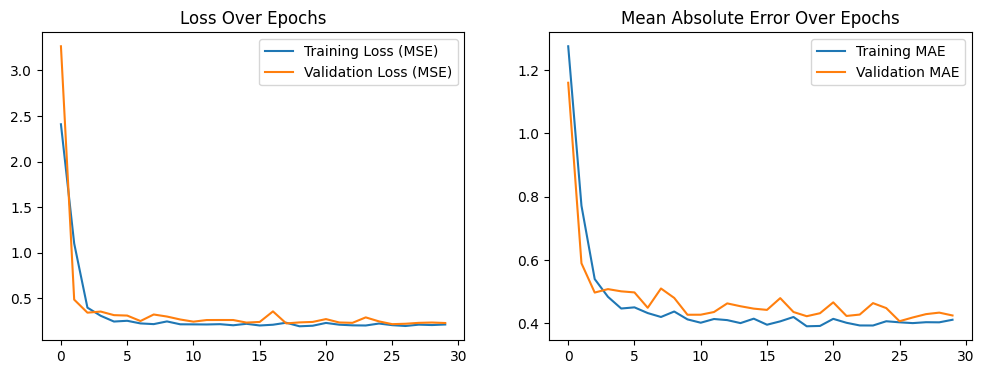

In [10]:
# Plotting the training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Loss Over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Mean Absolute Error Over Epochs')
plt.legend()

plt.show()

In [11]:
# Testing the model on a few validation samples
predictions = model.predict(X_test[:5])

print("\n--- Sample Predictions ---")
for i in range(5):
    print(f"Real Rating: {y_test[i]} | Predicted: {predictions[i][0]:.2f}")

1/1 [==============================] - 0s 303ms/step

--- Sample Predictions ---
Real Rating: 1 | Predicted: 1.47
Real Rating: 4 | Predicted: 4.40
Real Rating: 5 | Predicted: 4.35
Real Rating: 1 | Predicted: 1.40
Real Rating: 5 | Predicted: 4.45


## 7️⃣ Bonus Challenge: Try It On Yourself! 
Let's write our own reviews and pass them through our pipeline!


In [13]:
def predict_review(text):
    seq = tokenizer.texts_to_sequences([text])
    pad_seq = pad_sequences(seq, maxlen=max_length, padding="post", truncating="post")
    pred = model.predict(pad_seq, verbose=0)
    print(f"Review: '{text}' --> Predicted Rating: {pred[0][0]:.2f} / 5.0")

predict_review("This product is absolutely amazing and I love it!")
predict_review("Terrible experience, completely broke on day one.")
predict_review("It's okay, nothing special but gets the job done.")
predict_review("This is a cat")

Review: 'This product is absolutely amazing and I love it!' --> Predicted Rating: 1.72 / 5.0
Review: 'Terrible experience, completely broke on day one.' --> Predicted Rating: 1.77 / 5.0


Review: 'It's okay, nothing special but gets the job done.' --> Predicted Rating: 2.51 / 5.0
Review: 'This is a cat' --> Predicted Rating: 2.89 / 5.0


## 🌍 Extending to Real-World Datasets
Now that you know the pipeline (Tokenization $\rightarrow$ Padding $\rightarrow$ Embedding $\rightarrow$ Dense), let's apply it to a massive dataset! 

We will download a **Twitter Sentiment Analysis** dataset (27,000 tweets) and build an ANN to classify text into `Negative`, `Neutral`, or `Positive`.


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
import kagglehub

print("Downloading Kaggle Dataset...")
path = kagglehub.dataset_download("abhi8923shriv/sentiment-analysis-dataset")
print("Path to dataset files:", path)

In [ ]:
import shutil
dstination = '/content/'
shutil.move(path, dst=dstination)

In [ ]:
# Load and explore the new dataset
train_df = pd.read_csv(r'E:\NAVTTC-AI-Course\datasets\Sentiment Analysis Dataset\train.csv', encoding='latin1')
print(f"Real world dataset loaded! Size: {train_df.shape}")

train_df[['text', 'sentiment']].head()

Real world dataset loaded! Size: (27481, 10)


,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative


### 🧹 1. Cleaning and Preprocessing the Real Data
Real-world data is messy. We need to handle missing values (NaNs) and encode text labels (`positive`, `neutral`, `negative`) into numbers (`2`, `1`, `0`).


In [31]:
# 1. Drop missing rows
train_df.dropna(subset=['text', 'sentiment'], inplace=True)
print(f"Size after dropping NaNs: {train_df.shape}")

# 2. Map textual sentiments to integers (0, 1, 2) since Neural Networks output numbers
sentiment_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}
train_df['sentiment_encoded'] = train_df['sentiment'].map(sentiment_mapping)

train_df[['text', 'sentiment', 'sentiment_encoded']].head()

Size after dropping NaNs: (27480, 11)


,text,sentiment,sentiment_encoded
0,"I`d have responded, if I were going",neutral,1
1,Sooo SAD I will miss you here in San Diego!!!,negative,0
2,my boss is bullying me...,negative,0
3,what interview! leave me alone,negative,0
4,"Sons of ****, why couldn`t they put them on t...",negative,0


### 📝 2. Tokenization and Padding (Twitter Data)
We need a brand new Tokenizer because Twitter data uses completely different slang, hashtags, and words compared to product reviews.


In [32]:
# We limit the vocabulary to the top 10,000 most frequent words to avoid crashing memory
twitter_vocab_size = 10000
twitter_max_length = 100 # Tweets are slightly longer than our previous reviews

# 1. Tokenizer
twitter_tokenizer = Tokenizer(num_words=twitter_vocab_size, oov_token="<OOV>")
twitter_tokenizer.fit_on_texts(train_df['text'])

# 2. Convert to Sequences
X_twitter_seq = twitter_tokenizer.texts_to_sequences(train_df['text'])

# 3. Pad Sequences
X_twitter_padded = pad_sequences(X_twitter_seq, maxlen=twitter_max_length, padding="post", truncating="post")
y_twitter = train_df['sentiment_encoded'].values

print("X Tensor shape:", X_twitter_padded.shape)
print("y Tensor shape:", y_twitter.shape)

X Tensor shape: (27480, 100)
y Tensor shape: (27480,)


### ✂️ 3. Train / Test Split


In [10]:
from sklearn.model_selection import train_test_split
X_train_tw, X_test_tw, y_train_tw, y_test_tw = train_test_split(
    X_twitter_padded, y_twitter, test_size=0.2, random_state=42
)
print(f"Training set size: {X_train_tw.shape[0]} tweets")
print(f"Test set size: {X_test_tw.shape[0]} tweets")

Training set size: 21984 tweets
Test set size: 5496 tweets


### 🧠 4. Building a Multi-Class RNN 
Instead of predicting a single number (regression), we are now predicting **3 categories**. 
Therefore, our output layer will have `3 neurons`, and we will use the `softmax` activation to convert those 3 signals into **probabilities** (e.g., 80% confident it's positive, 10% neutral, 10% negative).

*Note: We are using `GlobalAveragePooling1D()` here instead of `Flatten()`. It averages all the word embeddings together, which reduces the number of parameters and speeds up training on larger inputs!*


In [33]:
twitter_model = models.Sequential([
    layers.Embedding(input_dim=twitter_vocab_size, output_dim=32, input_length=twitter_max_length),

    layers.SimpleRNN(128, return_sequences=True),
    layers.SimpleRNN(64, return_sequences=True),
    
    layers.GlobalAveragePooling1D(),
    

    
    # 3 categories (negative=0, neutral=1, positive=2)
    layers.Dense(3, activation="softmax") 
])

# We use sparse_categorical_crossentropy because our labels are single integers (0, 1, 2) rather than one-hot arrays
twitter_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
twitter_model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_4 (Embedding)     (None, 100, 32)           320000    
                                                                 
 simple_rnn_8 (SimpleRNN)    (None, 100, 128)          20608     
                                                                 
 simple_rnn_9 (SimpleRNN)    (None, 100, 64)           12352     
                                                                 
 global_average_pooling1d_2   (None, 64)               0         
 (GlobalAveragePooling1D)                                        
                                                                 
 dense_6 (Dense)             (None, 3)                 195       
                                                                 
Total params: 353,155
Trainable params: 353,155
Non-trainable params: 0
________________________________________________

### 🚀 5. Training the Twitter Sentiment Model


In [8]:
# !pip install tensorflow-datasets -q

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# Enable GPU Memory Growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU Memory Growth Enabled for {len(gpus)} GPU(s).")
    except Exception as e:
        print(e)

print("TensorFlow Version:", tf.__version__)

GPU Memory Growth Enabled for 1 GPU(s).
TensorFlow Version: 2.10.1


In [34]:
print("Training the Twitter Sentimental ANN...")
history_twitter = twitter_model.fit(
    X_train_tw, y_train_tw,
    epochs=10, # Keep epochs low to save time
    batch_size=128,
    validation_data=(X_test_tw, y_test_tw),
    verbose=1
)

Training the Twitter Sentimental ANN...
Epoch 1/10
172/172 [==============================] - 73s 408ms/step - loss: 1.1127 - accuracy: 0.3964 - val_loss: 1.0871 - val_accuracy: 0.4068
Epoch 2/10
172/172 [==============================] - 68s 394ms/step - loss: 1.0862 - accuracy: 0.4085 - val_loss: 1.0827 - val_accuracy: 0.4221
Epoch 3/10
172/172 [==============================] - 66s 385ms/step - loss: 1.0584 - accuracy: 0.4334 - val_loss: 1.0686 - val_accuracy: 0.4219
Epoch 4/10
172/172 [==============================] - 66s 383ms/step - loss: 1.0432 - accuracy: 0.4539 - val_loss: 1.0851 - val_accuracy: 0.4070
Epoch 5/10
172/172 [==============================] - 63s 366ms/step - loss: 1.0755 - accuracy: 0.4309 - val_loss: 1.0515 - val_accuracy: 0.4751
Epoch 6/10
172/172 [==============================] - 61s 355ms/step - loss: 1.0469 - accuracy: 0.4396 - val_loss: 1.0449 - val_accuracy: 0.4882
Epoch 7/10
172/172 [==============================] - 61s 355ms/step - loss: 0.9804 - accu

### 📊 6. Evaluating Multi-Class Performance


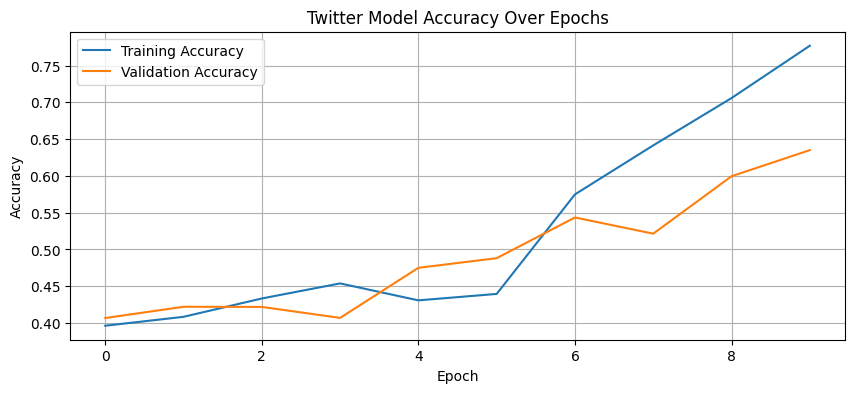

In [35]:
# Plotting the accuracy history
plt.figure(figsize=(10, 4))

plt.plot(history_twitter.history['accuracy'], label='Training Accuracy')
plt.plot(history_twitter.history['val_accuracy'], label='Validation Accuracy')
plt.title('Twitter Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

### 💡 7. Testing Fake Tweets! 
Let's test our Multi-Class Sentiment Classifier on a few live inputs.


In [39]:
def predict_tweet_sentiment(text):
    seq = twitter_tokenizer.texts_to_sequences([text])
    pad_seq = pad_sequences(seq, maxlen=twitter_max_length, padding="post", truncating="post")
    pred = twitter_model.predict(pad_seq, verbose=0)
    
    class_idx = np.argmax(pred[0])  # Find the index with the highest probability
    confidence = np.max(pred[0]) * 100
    
    sentiment_map = {0: "Negative 😡", 1: "Neutral 😐", 2: "Positive 😁"}
    
    print(f"Tweet: '{text}'")
    print(f"--> Sentiment: {sentiment_map[class_idx]} ({confidence:.1f}% confidence)\n")

predict_tweet_sentiment("I had the absolute worst day today, my car broke down and it was raining.")
predict_tweet_sentiment("Just bought some groceries.")
predict_tweet_sentiment("Wow! The new AI course at NAVTTC is fantastic, I'm learning so much!")
predict_tweet_sentiment('This is not a brave cat')

Tweet: 'I had the absolute worst day today, my car broke down and it was raining.'
--> Sentiment: Negative 😡 (92.1% confidence)

Tweet: 'Just bought some groceries.'
--> Sentiment: Neutral 😐 (83.6% confidence)

Tweet: 'Wow! The new AI course at NAVTTC is fantastic, I'm learning so much!'
--> Sentiment: Positive 😁 (66.7% confidence)

Tweet: 'This is not a brave cat'
--> Sentiment: Negative 😡 (82.6% confidence)

